# Smol LM - Tiny Transformer

A small decoder-only transformer with:
- **RoPE** (Rotary Position Embeddings)
- **GQA** (Grouped Query Attention)
- **RMSNorm**
- **SWiGLU** FFN
- **Weight tying** (token embedding & lm head)

Trains on Shakespeare in ~5 minutes on Colab's free T4 GPU.

In [1]:
import torch
import math
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from typing import List, Tuple
import time
import urllib.request
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## 1. Load & tokenize Shakespeare

In [2]:
# Download Shakespeare if not already present
import os
if not os.path.exists("shakespeare.txt"):
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    urllib.request.urlretrieve(url, "shakespeare.txt")
    print("Downloaded shakespeare.txt")

with open("shakespeare.txt", "r") as f:
    text = f.read()

chars = sorted(set(text))
vocab_size = len(chars)
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}

print(f"Text length: {len(text):,} chars")
print(f"Vocab size: {vocab_size} unique chars")

def encode(s: str) -> List[int]:
    return [char_to_idx[c] for c in s]

def decode(vec: List[int]) -> str:
    return "".join([idx_to_char[i] for i in vec])

Downloaded shakespeare.txt
Text length: 1,115,394 chars
Vocab size: 65 unique chars


In [3]:
cut = int(len(text) * 0.9)
train_data = encode(text[:cut])
val_data = encode(text[cut:])
print(f"Train tokens: {len(train_data):,}")
print(f"Val tokens:   {len(val_data):,}")

def get_batch(split: str, batch_size: int, context_length: int):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - context_length, (batch_size,))
    x = torch.stack([torch.tensor(d[i : i + context_length]) for i in ix.tolist()])
    y = torch.stack([torch.tensor(d[i + 1 : i + context_length + 1]) for i in ix.tolist()])
    return x.to(device), y.to(device)

Train tokens: 1,003,854
Val tokens:   111,540


## 2. Model Architecture

In [4]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return (x / rms) * self.weight

In [5]:
def precompute_rope_freqs(
    head_dim: int, max_seq_len: int, base: float = 10000.0
) -> Tuple[Tensor, Tensor]:
    freqs = 1.0 / (base ** (torch.arange(0, head_dim, 2).float() / head_dim))
    positions = torch.arange(max_seq_len).float()
    angles = torch.outer(positions, freqs)
    return torch.cos(angles), torch.sin(angles)


def apply_rope(x: Tensor, cos: Tensor, sin: Tensor) -> Tensor:
    seq_len = x.shape[2]
    cos = cos[:seq_len].unsqueeze(0).unsqueeze(0)
    sin = sin[:seq_len].unsqueeze(0).unsqueeze(0)
    x1 = x[..., ::2]
    x2 = x[..., 1::2]
    out1 = x1 * cos - x2 * sin
    out2 = x1 * sin + x2 * cos
    return torch.stack([out1, out2], dim=-1).flatten(-2)

In [6]:
def repeat_kv(x: Tensor, n_rep: int) -> Tensor:
    if n_rep == 1:
        return x
    b, n_kv, seq, hd = x.shape
    return (
        x[:, :, None, :, :]
        .expand(b, n_kv, n_rep, seq, hd)
        .reshape(b, n_kv * n_rep, seq, hd)
    )


class GQA(nn.Module):
    def __init__(
        self,
        d_model: int,
        n_heads: int,
        head_dim: int,
        n_kv_heads: int,
        max_seq_len: int,
    ) -> None:
        super().__init__()
        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads
        self.head_dim = head_dim
        self.n_rep = n_heads // n_kv_heads
        self.q_proj = nn.Linear(d_model, n_heads * head_dim)
        self.k_proj = nn.Linear(d_model, n_kv_heads * head_dim)
        self.v_proj = nn.Linear(d_model, n_kv_heads * head_dim)
        self.o_proj = nn.Linear(n_heads * head_dim, d_model)
        cos, sin = precompute_rope_freqs(head_dim, max_seq_len)
        self.register_buffer("rope_cos", cos)
        self.register_buffer("rope_sin", sin)

    def forward(self, x: Tensor) -> Tensor:
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)
        b, seq, _ = x.shape
        q = q.view(b, seq, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(b, seq, self.n_kv_heads, self.head_dim).transpose(1, 2)
        v = v.view(b, seq, self.n_kv_heads, self.head_dim).transpose(1, 2)
        q = apply_rope(q, self.rope_cos, self.rope_sin)
        k = apply_rope(k, self.rope_cos, self.rope_sin)
        k = repeat_kv(k, self.n_rep)
        v = repeat_kv(v, self.n_rep)
        scale = 1.0 / math.sqrt(self.head_dim)
        scores = (q @ k.transpose(-2, -1)) * scale
        mask = torch.triu(torch.ones(seq, seq, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float("-inf"))
        weights = F.softmax(scores, dim=-1)
        weights = F.dropout(weights, p=0.2, training=self.training)
        out = weights @ v
        out = out.transpose(1, 2).contiguous()
        out = out.view(b, seq, self.n_heads * self.head_dim)
        return self.o_proj(out)

In [7]:
class SWiGLU(nn.Module):
    def __init__(self, d_model: int, hidden_dim: int) -> None:
        super().__init__()
        self.w_gate = nn.Linear(d_model, hidden_dim)
        self.w_up = nn.Linear(d_model, hidden_dim)
        self.w_down = nn.Linear(hidden_dim, d_model)

    def forward(self, x: Tensor):
        gate = F.silu(self.w_gate(x))
        up = self.w_up(x)
        return F.dropout(self.w_down(gate * up), p=0.2, training=self.training)

In [8]:
class TransformerBlock(nn.Module):
    def __init__(
        self,
        d_model: int,
        n_kv_heads: int,
        n_heads: int,
        ffn_hidden_dims: int,
        max_seq_len: int,
    ) -> None:
        super().__init__()
        self.attn_norm = RMSNorm(d_model)
        self.ffn_norm = RMSNorm(d_model)
        head_dim = d_model // n_heads
        self.attention = GQA(d_model, n_heads, head_dim, n_kv_heads, max_seq_len)
        self.ffn = SWiGLU(d_model, ffn_hidden_dims)

    def forward(self, x: Tensor):
        x = x + self.attention(self.attn_norm(x))
        x = x + self.ffn(self.ffn_norm(x))
        return x

In [9]:
class Smol_LM(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 256,
        n_heads: int = 8,
        n_kv_heads: int = 2,
        num_layers: int = 6,
        ffn_hidden_mult: int = 4,
        max_seq_len: int = 256,
    ) -> None:
        super().__init__()
        self.max_seq_len = max_seq_len
        head_dim = d_model // n_heads
        ffn_hidden_dims = ffn_hidden_mult * d_model
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.layers = nn.ModuleList(
            [
                TransformerBlock(d_model, n_kv_heads, n_heads, ffn_hidden_dims, max_seq_len)
                for _ in range(num_layers)
            ]
        )
        self.final_norm = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.token_emb.weight = self.lm_head.weight
        self.apply(self._init_weights)

    def _init_weights(self, module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, x: Tensor, targets: Tensor | None = None) -> Tuple[Tensor, Tensor | None]:
        x = self.token_emb(x)
        for layer in self.layers:
            x = layer(x)
        x = self.final_norm(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx: Tensor, max_new_tokens: int, temperature: float = 1.0) -> Tensor:
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.max_seq_len :]
            logits, _ = self.forward(idx_cond)
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

## 3. Training

In [10]:
d_model = 256
n_heads = 8
n_kv_heads = 2
num_layers = 6
max_seq_len = 256
batch_size = 64
learning_rate = 3e-4
max_iters = 5000
eval_interval = 500
eval_iters = 20

model = Smol_LM(
    vocab_size=vocab_size,
    d_model=d_model,
    n_heads=n_heads,
    n_kv_heads=n_kv_heads,
    num_layers=num_layers,
    max_seq_len=max_seq_len,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {total_params:,}")
print(f"Context length: {max_seq_len}")
print(f"Batch size: {batch_size}")

Model params: 5,739,264
Context length: 256
Batch size: 64


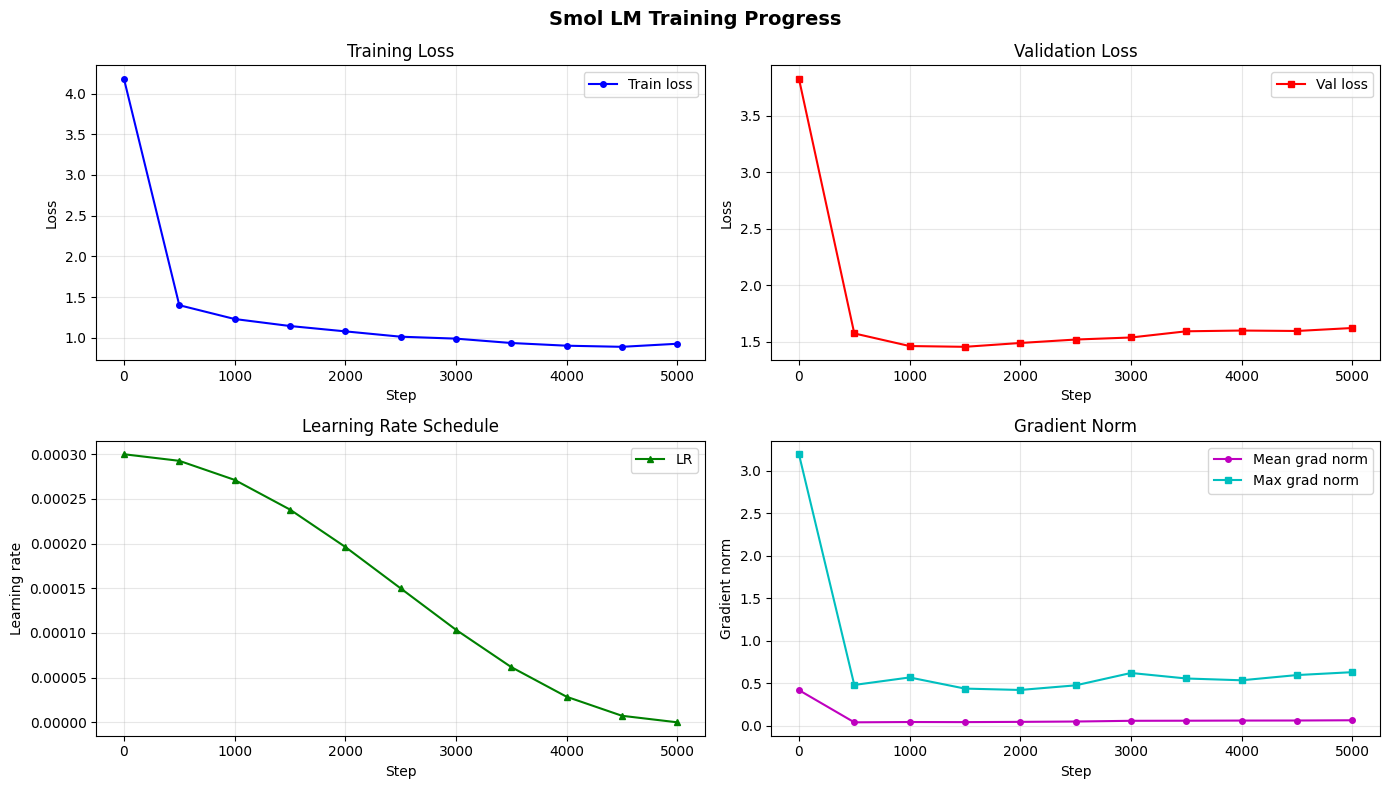

Generated sample:
ROMEO: for such a night I do?

BRAKENBURY:
Well, well deserved with my son Richmond's care,
And well content as a man to prove all
At all unhappily by my father's son.

DUKE OF YORK:
Why knows not my tongue 
------------------------------------------------------------


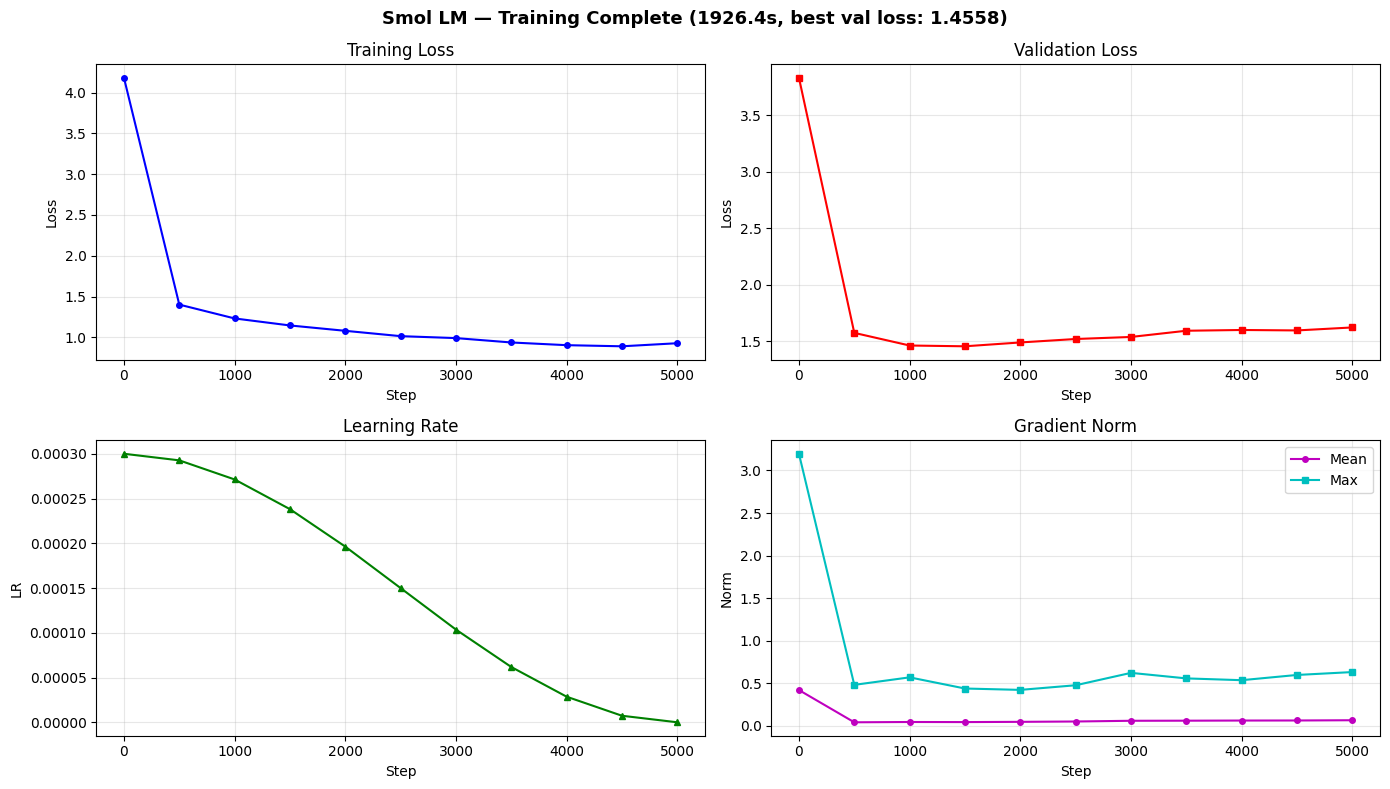

Training complete in 1926.4s — Best val loss: 1.4558


In [11]:
plt.ion()  # interactive mode on

@torch.no_grad()
def evaluate(model, batch_size, context_length, num_batches=20):
    model.eval()
    total_loss = 0.0
    for _ in range(num_batches):
        x, y = get_batch("val", batch_size, context_length)
        _, loss = model(x, y)
        total_loss += loss.item()
    model.train()
    return total_loss / num_batches


def plot_progress(steps, train_losses, val_losses, lrs, grad_means, grad_maxs, sample_text=""):
    clear_output(wait=True)
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle("Smol LM Training Progress", fontsize=14, fontweight="bold")

    axes[0, 0].plot(steps, train_losses, "b-o", markersize=4, label="Train loss")
    axes[0, 0].set_xlabel("Step")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].set_title("Training Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(steps, val_losses, "r-s", markersize=4, label="Val loss")
    axes[0, 1].set_xlabel("Step")
    axes[0, 1].set_ylabel("Loss")
    axes[0, 1].set_title("Validation Loss")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(steps, lrs, "g-^", markersize=4, label="LR")
    axes[1, 0].set_xlabel("Step")
    axes[1, 0].set_ylabel("Learning rate")
    axes[1, 0].set_title("Learning Rate Schedule")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(steps, grad_means, "m-o", markersize=4, label="Mean grad norm")
    axes[1, 1].plot(steps, grad_maxs, "c-s", markersize=4, label="Max grad norm")
    axes[1, 1].set_xlabel("Step")
    axes[1, 1].set_ylabel("Gradient norm")
    axes[1, 1].set_title("Gradient Norm")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    if sample_text:
        print("Generated sample:")
        print(sample_text)
        print("-" * 60)


optimizer = AdamW(model.parameters(), lr=learning_rate)
scheduler = CosineAnnealingLR(optimizer, T_max=max_iters)

steps_log, train_losses, val_losses, lrs, grad_means, grad_maxs = [], [], [], [], [], []
start_time = time.time()
best_val_loss = float("inf")

for step in range(max_iters + 1):
    x, y = get_batch("train", batch_size, max_seq_len)
    optimizer.zero_grad()
    _, loss = model(x, y)
    loss.backward()

    # Compute per-param grad norms before clipping
    param_norms = []
    for p in model.parameters():
        if p.grad is not None:
            param_norms.append(p.grad.norm().item())
    grad_mean = sum(param_norms) / len(param_norms) if param_norms else 0.0
    grad_max = max(param_norms) if param_norms else 0.0

    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    if step % eval_interval == 0:
        val_loss = evaluate(model, batch_size, max_seq_len, eval_iters)
        current_lr = scheduler.get_last_lr()[0]

        steps_log.append(step)
        train_losses.append(loss.item())
        val_losses.append(val_loss)
        lrs.append(current_lr)
        grad_means.append(grad_mean)
        grad_maxs.append(grad_max)

        elapsed = time.time() - start_time

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "smol_lm_best.pt")

        # Generate sample text
        sample_text = ""
        if step > 0:
            context = torch.tensor([encode("ROMEO: ")], dtype=torch.long, device=device)
            output = model.generate(context, max_new_tokens=200, temperature=0.8)
            sample_text = decode(output[0].tolist())

        print(f"Step {step:5d} | train loss {loss.item():.4f} | val loss {val_loss:.4f} | LR {current_lr:.2e} | elapsed {elapsed:.1f}s")
        if val_loss == best_val_loss:
            print(f"  -> saved best model (val_loss={val_loss:.4f})")

        plot_progress(steps_log, train_losses, val_losses, lrs, grad_means, grad_maxs, sample_text)

total_time = time.time() - start_time

# Final clean plot (no clear_output so it persists)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"Smol LM — Training Complete ({total_time:.1f}s, best val loss: {best_val_loss:.4f})", fontsize=13, fontweight="bold")

axes[0, 0].plot(steps_log, train_losses, "b-o", markersize=4)
axes[0, 0].set_title("Training Loss"); axes[0, 0].set_xlabel("Step"); axes[0, 0].set_ylabel("Loss"); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(steps_log, val_losses, "r-s", markersize=4)
axes[0, 1].set_title("Validation Loss"); axes[0, 1].set_xlabel("Step"); axes[0, 1].set_ylabel("Loss"); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(steps_log, lrs, "g-^", markersize=4)
axes[1, 0].set_title("Learning Rate"); axes[1, 0].set_xlabel("Step"); axes[1, 0].set_ylabel("LR"); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(steps_log, grad_means, "m-o", markersize=4, label="Mean")
axes[1, 1].plot(steps_log, grad_maxs, "c-s", markersize=4, label="Max")
axes[1, 1].set_title("Gradient Norm"); axes[1, 1].set_xlabel("Step"); axes[1, 1].set_ylabel("Norm"); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Training complete in {total_time:.1f}s — Best val loss: {best_val_loss:.4f}")

## 4. Generate text from the trained model

In [12]:
# Load best model
model.load_state_dict(torch.load("smol_lm_best.pt", map_location=device))
model.eval()

prompt = "JULIET: "
context = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
output = model.generate(context, max_new_tokens=500, temperature=0.7)
print(decode(output[0].tolist()))

JULIET: have the nuptial parts, it cannot
be, let me speak for any where they were needful,
mile in the each other of the heavy mother,
Here may be sent by their bed into his poison.
There is the sea of day of the hand, that I may starvet
And believe him, which we parted him but one.

Second Citizen:
Why, who can you have all dead in the friar
that you have done an hour mother than your father
she will not stand for she will have here it is
meaning to be more made to thou a man of move a
contract and we
